# **!!_12_Training errors for different N on the same scale along the vertical axis**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 7.5 MB/s eta 0:00:00
FULL DATASET (441 points, one outlier)
Removed normal points: 396
Remaining points: 45 (outliers: 1)
Outlier percentage: 2.22%
The true outlier is at index 24 (zero-based index 23)

Q = 45, N_x = 2, N_y = 1
N_min = 2.3106, N_max = 31.6667


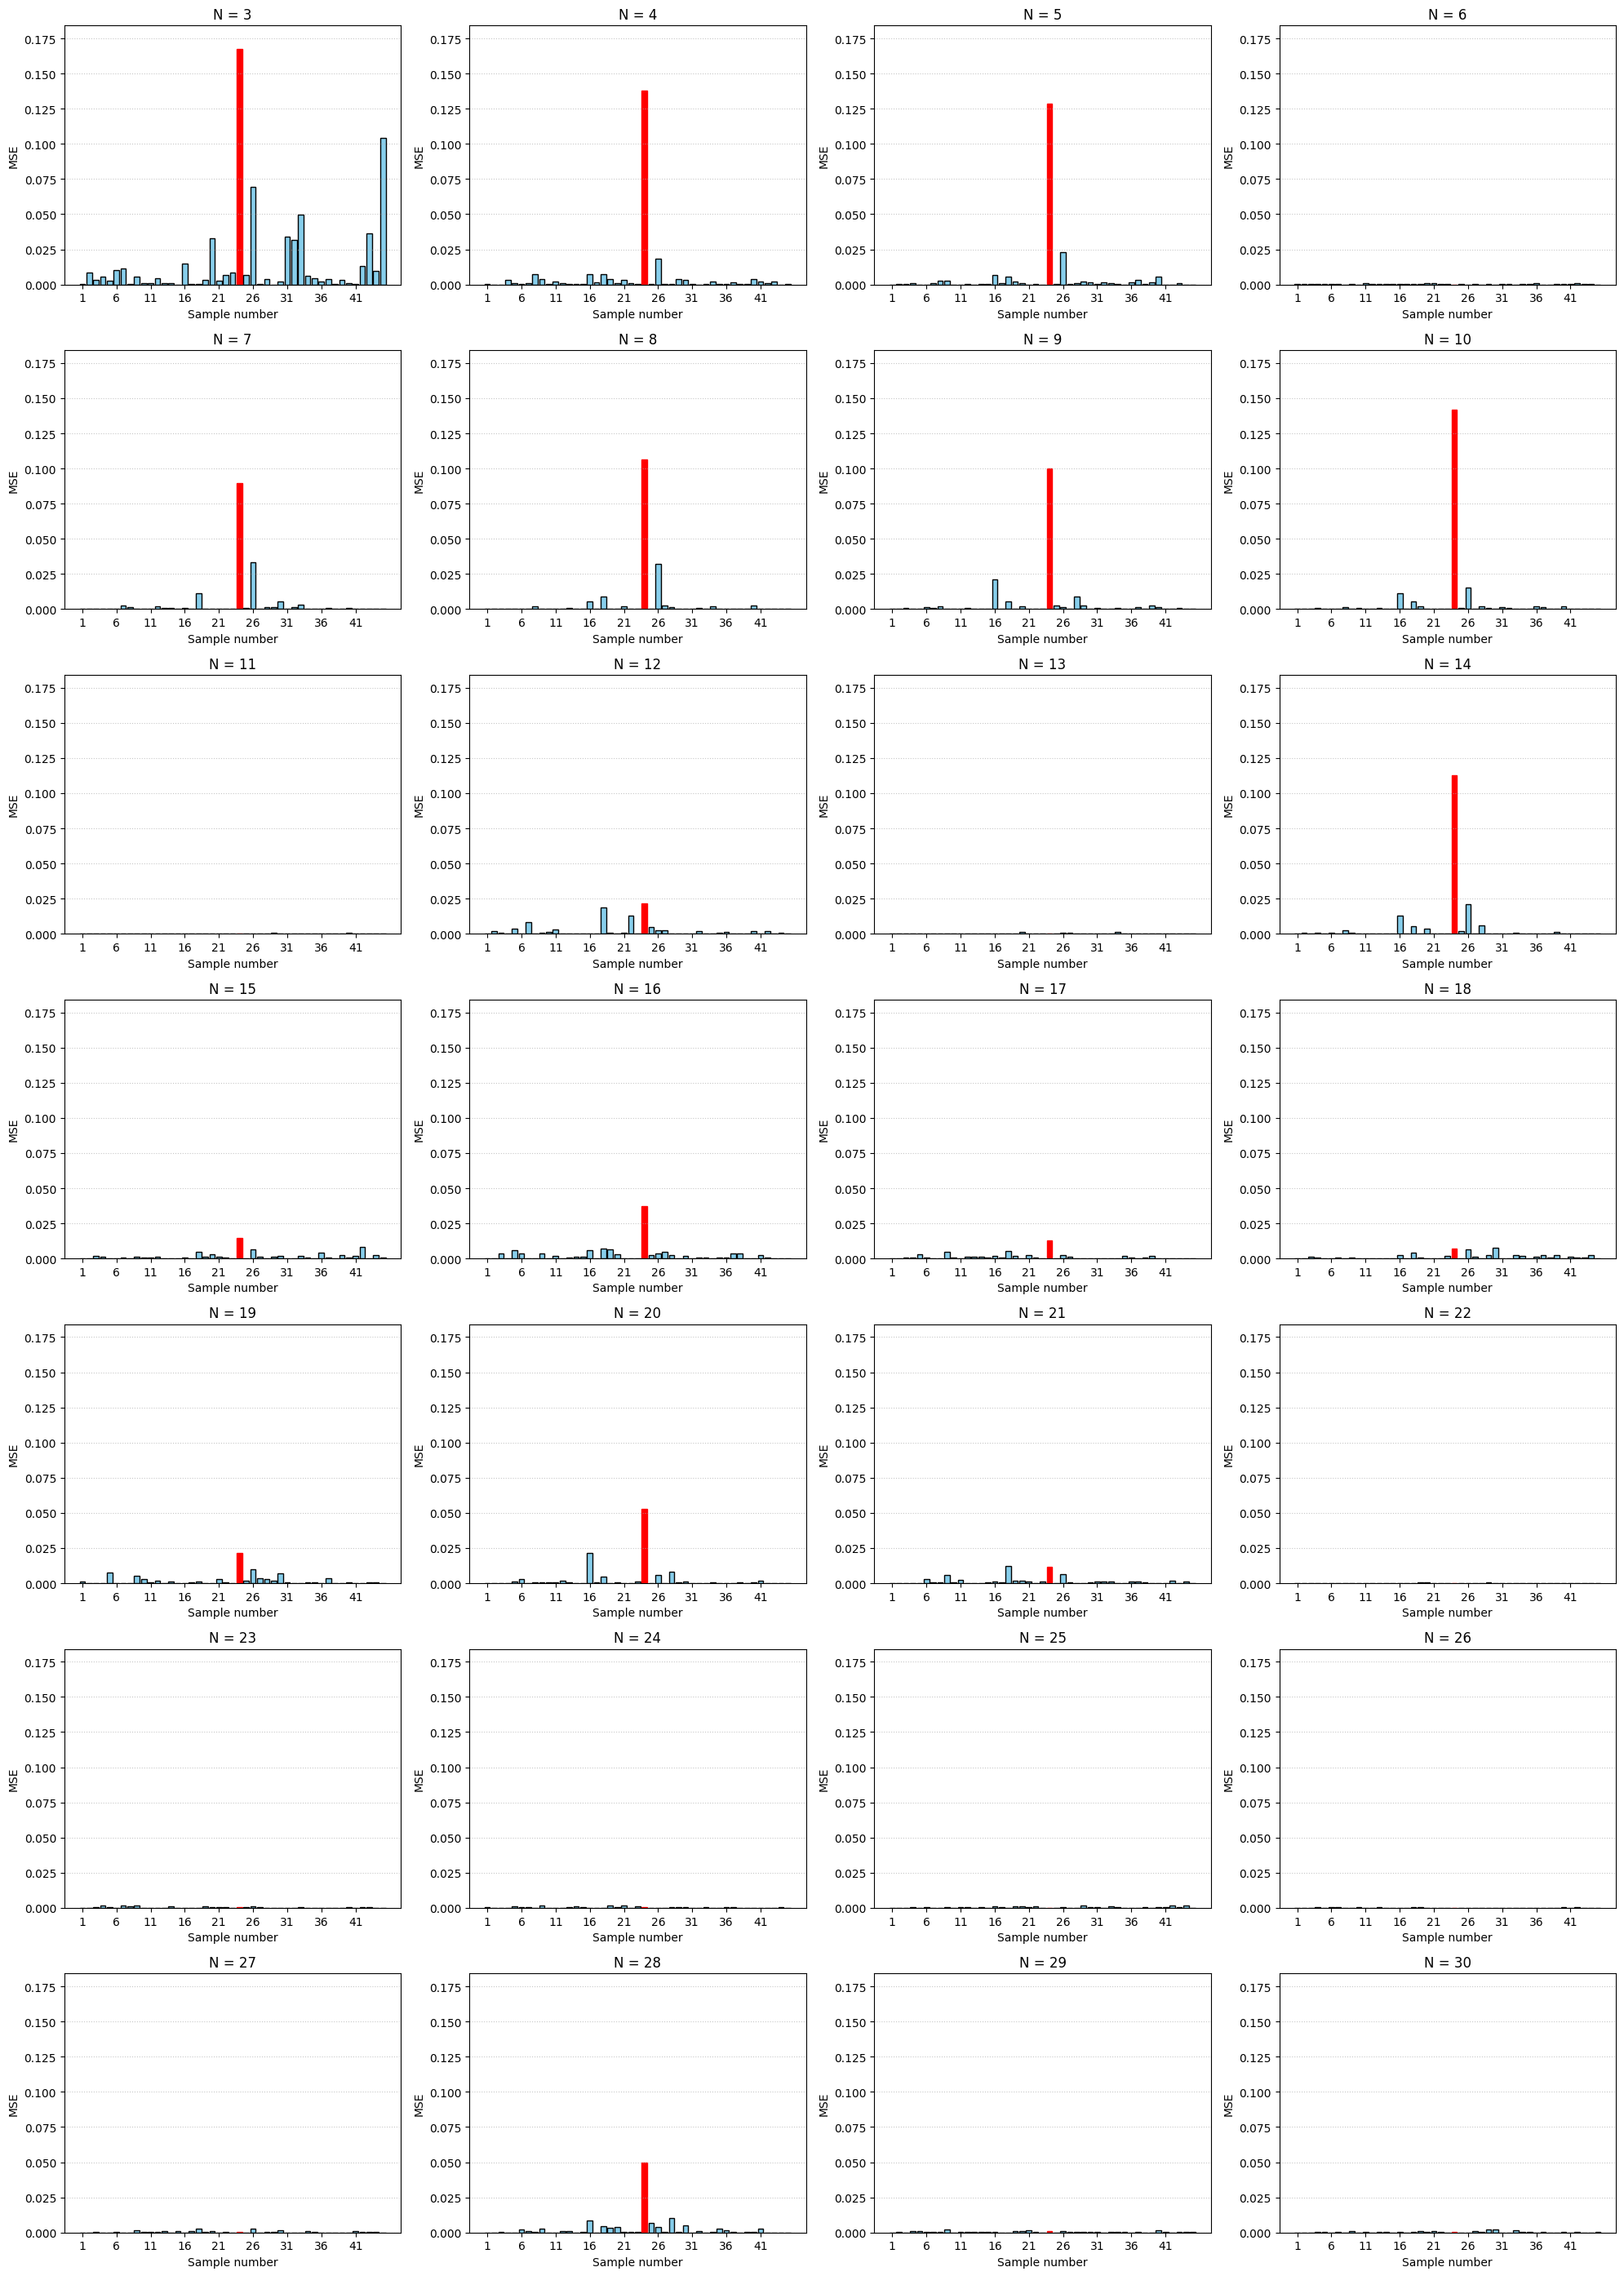

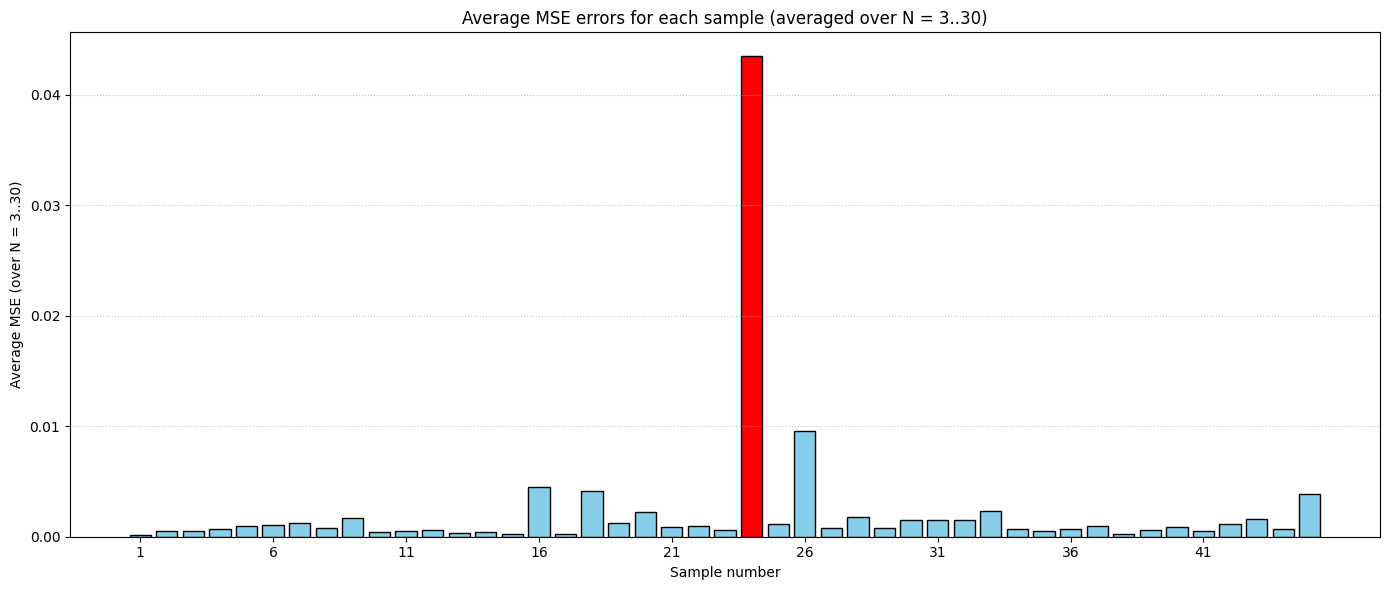


Average error for the true outlier (sample 24): 0.043461
Maximum average error: 0.043461 at sample 24


In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pyod

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import math

# ------------------------------------------------------------
# 1. Generation of the full elliptic paraboloid dataset with an outlier
#    Features: x1, x2 ; target variable: y = x1^2 - x2^2
# ------------------------------------------------------------
x1 = np.arange(-1.0, 1.05, 0.1)
x2 = np.arange(-1.0, 1.05, 0.1)
X1grid, X2grid = np.meshgrid(x1, x2)
Ygrid = X1grid**2 - X2grid**2

# Inject outlier at point (x1=0, x2=0) with value y = 0.45
mask_out = (np.abs(X1grid) < 1e-10) & (np.abs(X2grid) < 1e-10)
Ygrid[mask_out] = 0.45

points_full = np.column_stack((X1grid.ravel(), X2grid.ravel(), Ygrid.ravel()))
labels_full = np.zeros(len(points_full), dtype=int)
labels_full[np.where(mask_out.ravel())[0]] = 1

print("="*80)
print("FULL DATASET (441 points, one outlier)")
print("="*80)

# ------------------------------------------------------------
# 2. Random removal of 90% of normal points
# ------------------------------------------------------------
np.random.seed(42)
normal_indices = np.where(labels_full == 0)[0]
n_remove = int(0.90 * len(normal_indices))
remove_idx = np.random.choice(normal_indices, size=n_remove, replace=False)
keep_mask = np.ones(len(points_full), dtype=bool)
keep_mask[remove_idx] = False
points = points_full[keep_mask]
labels_true = labels_full[keep_mask]

print(f"Removed normal points: {n_remove}")
print(f"Remaining points: {len(points)} (outliers: {labels_true.sum()})")
print(f"Outlier percentage: {labels_true.sum()/len(points)*100:.2f}%")

# ------------------------------------------------------------
# 3. Data preparation for NNF: inputs (x1,x2) -> output (y)
# ------------------------------------------------------------
X_nnf = points[:, :2]   # x1, x2
y_nnf = points[:, 2]    # y

Q = X_nnf.shape[0]
N_x = X_nnf.shape[1]   # 2
N_y = 1

# Scaling to [-1, 1]
def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X_nnf)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y_nnf.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Index of the true outlier (zero-based)
true_outlier_idx = np.where(labels_true == 1)[0][0]
print(f"The true outlier is at index {true_outlier_idx+1} (zero-based index {true_outlier_idx})")

# ------------------------------------------------------------
# 4. Calculation of hidden layer neuron count bounds (empirical formulas)
# ------------------------------------------------------------
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y))
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1)
print(f"\nQ = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")

# ------------------------------------------------------------
# 5. Training for N from 3 to 30 and building all histograms
# ------------------------------------------------------------
N_range = range(3, 31)          # 3..30 inclusive
n_N = len(N_range)
sum_errors = np.zeros(Q)        # for accumulating error sums

# First, compute all errors to find global max for consistent scaling
all_errors = []
for N in N_range:
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(N_x, N),
        nn.Tanh(),
        nn.Linear(N, N_y)
    )
    criterion = nn.MSELoss()
    optimizer = optim.Rprop(model.parameters(), lr=0.01)
    model.train()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    all_errors.append(errors)
    sum_errors += errors

# Find global maximum across all N for consistent y-axis scaling
global_max = np.max(all_errors)

# Create a grid of subplots 7x4
n_rows, n_cols = 7, 4
fig_all, axes_all = plt.subplots(n_rows, n_cols, figsize=(20, 28))

for idx, N in enumerate(N_range):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes_all[row, col]

    errors = all_errors[idx]
    examples = np.arange(1, Q+1)
    bars = ax.bar(examples, errors, color='skyblue', edgecolor='black')
    bars[true_outlier_idx].set_color('red')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Sample number')
    ax.set_ylabel('MSE')
    ax.set_xticks(examples[::5])
    ax.set_ylim(0, global_max * 1.1)  # consistent vertical scale
    ax.grid(axis='y', linestyle=':', alpha=0.7)

# Hide extra subplots (if any)
total_plots = n_rows * n_cols
if n_N < total_plots:
    for i in range(n_N, total_plots):
        axes_all.flat[i].set_visible(False)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Calculation of average errors for each sample over all N
# ------------------------------------------------------------
mean_errors = sum_errors / n_N

# ------------------------------------------------------------
# 7. Histogram of average errors
# ------------------------------------------------------------
print("\n\n")
plt.figure(figsize=(14, 6))
examples = np.arange(1, Q+1)
colors = ['red' if i == true_outlier_idx else 'skyblue' for i in range(Q)]
bars = plt.bar(examples, mean_errors, color=colors, edgecolor='black')
plt.xlabel('Sample number')
plt.ylabel('Average MSE (over N = 3..30)')
plt.title('Average MSE errors for each sample (averaged over N = 3..30)')
plt.xticks(examples[::5])
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Additional information
# ------------------------------------------------------------
print(f"\nAverage error for the true outlier (sample {true_outlier_idx+1}): {mean_errors[true_outlier_idx]:.6f}")
print(f"Maximum average error: {np.max(mean_errors):.6f} at sample {np.argmax(mean_errors)+1}")